# 01: Demonstration of Target Creation


A fault tolerant quantum computer is the goal post driving innovation forward in the fields of 2D materials, quantum sensing, atomic physics and many more. While many proposals exist for methodologies to construct one, what we can do now is simulate what it could look like in the first place. 

As we advance the field of quantum computation, it is imperative to understand how decisions made in the design process affect the efficiency and scalability of our devices. Even more imperative, how can one transpile with the different implementations various gimicks in mind? Different fault tolerant codes have their own shortcomings and advantages, which FTTarget hopes to help unearth. 

In [97]:
# imports

import time
import math
import networkx as nx
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.random import random_circuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from backend.FaultTolerantTarget import FTTarget

def make_test_qc(num_q = 100, dep = 10):
    return random_circuit(num_qubits=num_q, depth=dep, measure=False, seed = 67)


To start, consider a generalized, fault tolerant quantum computer running a Surface code. We will utilize a basis gate set of Hadamard, S, T and CX gates, each with their error and duration tied to the clock cycle by depth of the code itself. 

In [110]:
# Define base hardware parameters
d = 5  # Surface code distance (can be 5, 7, 9, etc.)
t_c = 1e-6  # Cycle time (1 microsecond)
p_phys = 1e-3  # Physical error rate (0.1%)
p_thresh = 3e-3 # threshold error rate (0.3%) 

# Calculate the baseline logical error rate per cycle
def p_L(distance, phys_err):
    return (0.1 * (phys_err/p_thresh)**((distance + 1) / 2))

top = {
    "type": "tiled_k_nearest",
    "n_blocks_row": 1,
    "n_blocks_col": 1,
    "n" : 10,
    "m": 10,
    "k_intra":1,
    "k_inter": 1,
}

# Profile reflects the IBM basis evaluated with Fault-Tolerant Surface Code costs
profile = {
    "sq_gates": {
        "RZGate": {
            "error": d * p_L(d, p_phys), 
            # Arbitrary phase rotations require Magic State Distillation and synthesis in FT
            "duration": 15 * d * t_c  
        },
        "XGate": {
            "error": d * p_L(d, p_phys), 
            # X is a Pauli (Clifford), so it is fast (often transversal)
            "duration": d * t_c
        },
        "SXGate": {
            "error": d * p_L(d, p_phys), 
            # SX (sqrt-X) is a Clifford gate, so it is fast
            "duration": d * t_c
        }
    },
    "two_q_gates": {
        "CXGate": {
            # CX is a Clifford performed via Lattice Surgery
            "local_error": d * p_L(d, p_phys), 
            "local_duration": d * t_c
        }
    },
    "inter_device_gates": {
        "CXGate": {
            # Represents inter-block gate teleportation, manually injected 0.5% error rate 
            "inter_error": 0.05, 
            "inter_duration": 2 * d * t_c
        }
    }
}

args = {"topology": top, "profile": profile}

In [111]:
d=3

print(p_L(d, p_phys))
profile["two_q_gates"]["CXGate"]["local_error"]

0.011111111111111112


0.018518518518518514

In [112]:
# we create the FTTarget out of these arguments, giving the following 10x10 square grid of logical connectivity
one_device = FTTarget(args)

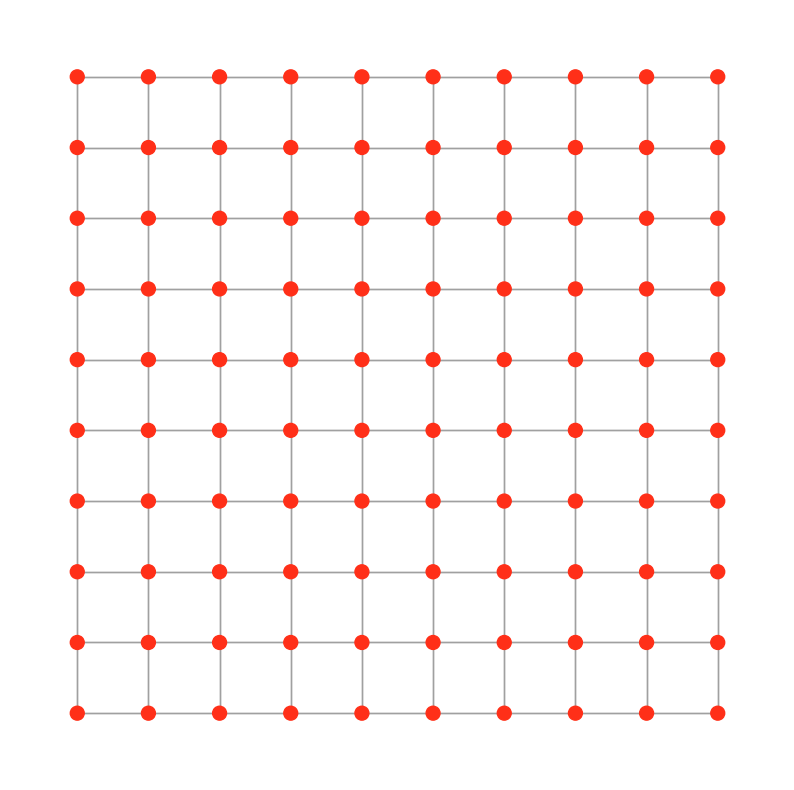

In [113]:
one_device.plot()

We then can transpile our random circuit onto our hardware. It has 100 qubits with a circuit depth of 10

In [114]:
qc = make_test_qc()

In [115]:
# a generic qiskit preset pass manager using highest optimization level such that it considers the scheduling method
pm_one_device = generate_preset_pass_manager(target=one_device, optimization_level=3, scheduling_method="alap", seed_transpiler=67)

In [116]:
def transpilation_tracker(pass_, dag, time, property_set, count):
        # Get the name of the pass
        pass_name = pass_.name()
        
        # Print the progress
        print(f"Step {count:03d} | {pass_name:<30} | Time: {time:.4f}s | Gate Count: {dag.count_ops()}")

In [117]:
transpiled_circuit_on_one = pm_one_device.run(qc, callback=transpilation_tracker) 

Step 000 | ContainsInstruction            | Time: 0.0000s | Gate Count: {'c3sx': 72, 'rzx': 2, 'u2': 9, 'z': 7, 'r': 8, 'rcccx': 83, 'sxdg': 10, 'id': 9, 'y': 10, 'dcx': 1, 't': 5, 'u1': 9, 's': 9, 'rccx': 12, 'h': 16, 'u3': 8, 'ry': 8, 'sdg': 6, 'cu': 3, 'cx': 2, 'x': 6, 'ccx': 10, 'u': 5, 'sx': 5, 'ccz': 15, 'cswap': 12, 'tdg': 5, 'cs': 1, 'cry': 2, 'ecr': 2, 'cy': 1, 'p': 11, 'rx': 9, 'swap': 1, 'xx_plus_yy': 1, 'csdg': 2, 'rz': 5, 'cu1': 1, 'ch': 3, 'iswap': 1, 'rzz': 3, 'ryy': 1, 'csx': 2, 'crx': 1, 'cu3': 2, 'cp': 1, 'rxx': 1}
Step 001 | UnitarySynthesis               | Time: 0.0000s | Gate Count: {'c3sx': 72, 'rzx': 2, 'u2': 9, 'z': 7, 'r': 8, 'rcccx': 83, 'sxdg': 10, 'id': 9, 'y': 10, 'dcx': 1, 't': 5, 'u1': 9, 's': 9, 'rccx': 12, 'h': 16, 'u3': 8, 'ry': 8, 'sdg': 6, 'cu': 3, 'cx': 2, 'x': 6, 'ccx': 10, 'u': 5, 'sx': 5, 'ccz': 15, 'cswap': 12, 'tdg': 5, 'cs': 1, 'cry': 2, 'ecr': 2, 'cy': 1, 'p': 11, 'rx': 9, 'swap': 1, 'xx_plus_yy': 1, 'csdg': 2, 'rz': 5, 'cu1': 1, 'ch': 3, 'is

In [118]:
#  helper function to estimate the overal fidelity of our random circuit implementation by multiplying error probability per gate operation
#  Since actual fidelity would depend on ordering and purpose of the circuit, this is made as a general tool for comparison
def estimate_circuit_fidelity(scheduled_circuit, target):
    total_fidelity = 1.0
    
    # Iterate through each instruction in the circuit
    for instruction in scheduled_circuit.data:
        gate = instruction.operation
        qubits = tuple(scheduled_circuit.find_bit(q).index for q in instruction.qubits)
        
        # Look up instruction properties in the Target
        try:
            props = target[gate.name][qubits]
            if props and props.error:
                total_fidelity *= (1 - props.error)
        except KeyError:
            # Skip gates like barriers or ideal operations with no error data
            continue
            
    return total_fidelity

In [119]:
print(f"Estimated fidelity of random circuit: {estimate_circuit_fidelity(transpiled_circuit_on_one, one_device)}")
# TODO print out gate counts and number of inter-device connections instead. Save to a dataframe perchance

Estimated fidelity of random circuit: 2.5032428234951775e-125


One might wonder how the transpilation is affected when we consider a networked grid instead of a singular device, given the network connections will have a higher error intrinsicly.

In [120]:
top = {
        "type": "tiled_k_nearest",
        "n_blocks_row": 2,
        "n_blocks_col": 2,
        "n" : 5,
        "m": 5,
        "k_intra":1,
        "k_inter": 1,
        
    }
# now using 4 devices with swap's allowed between them
args = {"topology": top, "profile": profile}

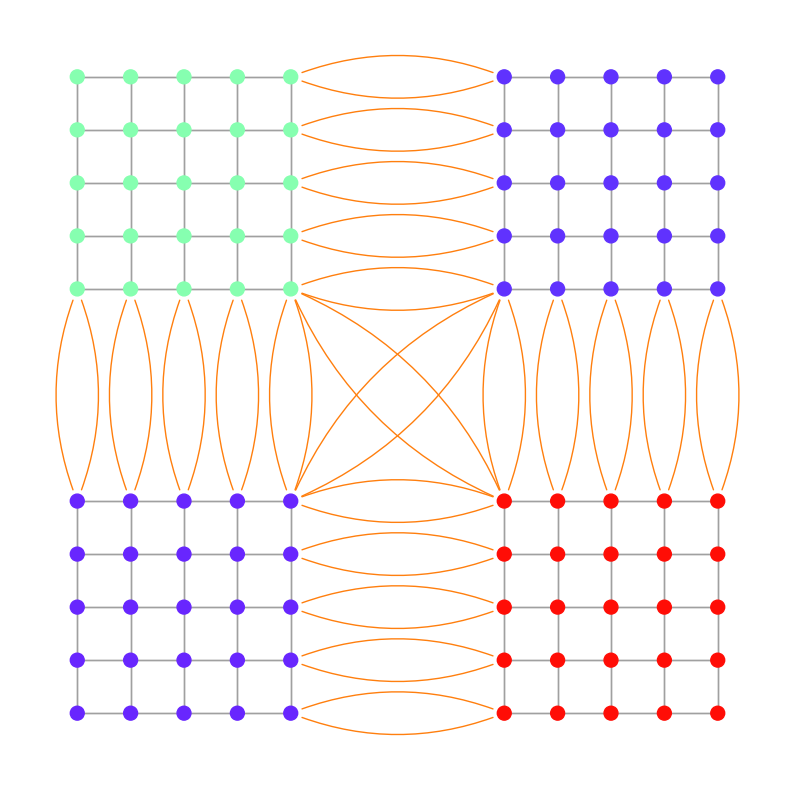

In [ ]:
four_devices = FTTarget(args)
four_devices.plot()
pm = generate_preset_pass_manager(target=four_devices, optimization_level=3, scheduling_method="alap",seed_transpiler=67)


In [122]:
transpiled_circuit_on_four = pm.run(qc, callback=transpilation_tracker) 

Step 000 | ContainsInstruction            | Time: 0.0000s | Gate Count: {'c3sx': 72, 'rzx': 2, 'u2': 9, 'z': 7, 'r': 8, 'rcccx': 83, 'sxdg': 10, 'id': 9, 'y': 10, 'dcx': 1, 't': 5, 'u1': 9, 's': 9, 'rccx': 12, 'h': 16, 'u3': 8, 'ry': 8, 'sdg': 6, 'cu': 3, 'cx': 2, 'x': 6, 'ccx': 10, 'u': 5, 'sx': 5, 'ccz': 15, 'cswap': 12, 'tdg': 5, 'cs': 1, 'cry': 2, 'ecr': 2, 'cy': 1, 'p': 11, 'rx': 9, 'swap': 1, 'xx_plus_yy': 1, 'csdg': 2, 'rz': 5, 'cu1': 1, 'ch': 3, 'iswap': 1, 'rzz': 3, 'ryy': 1, 'csx': 2, 'crx': 1, 'cu3': 2, 'cp': 1, 'rxx': 1}
Step 001 | UnitarySynthesis               | Time: 0.0000s | Gate Count: {'c3sx': 72, 'rzx': 2, 'u2': 9, 'z': 7, 'r': 8, 'rcccx': 83, 'sxdg': 10, 'id': 9, 'y': 10, 'dcx': 1, 't': 5, 'u1': 9, 's': 9, 'rccx': 12, 'h': 16, 'u3': 8, 'ry': 8, 'sdg': 6, 'cu': 3, 'cx': 2, 'x': 6, 'ccx': 10, 'u': 5, 'sx': 5, 'ccz': 15, 'cswap': 12, 'tdg': 5, 'cs': 1, 'cry': 2, 'ecr': 2, 'cy': 1, 'p': 11, 'rx': 9, 'swap': 1, 'xx_plus_yy': 1, 'csdg': 2, 'rz': 5, 'cu1': 1, 'ch': 3, 'is

In [123]:
print(f"Estimated Circuit Fidelity: {estimate_circuit_fidelity(transpiled_circuit_on_four, four_devices)}")

# TODO print out gate counts and number of inter-device connections instead. Save to a dataframe perchance

Estimated Circuit Fidelity: 5.3306140732786555e-143


We can see the estimated fidelity has significantly gone up, which is understandable given the higher fidelity of inter-device networking. Let's build another device with 10 total instead

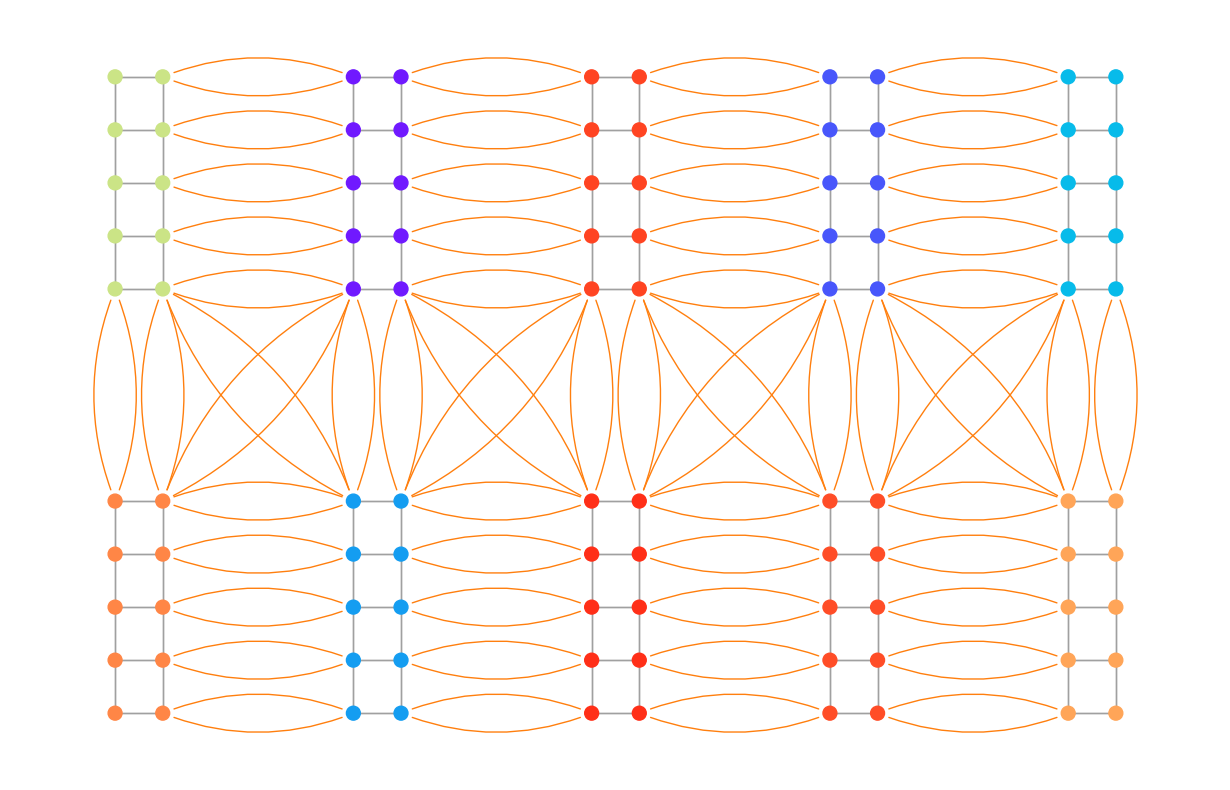

In [ ]:
top = {
        "type": "tiled_k_nearest",
        "n_blocks_row": 2,
        "n_blocks_col": 5,
        "n" : 5,
        "m": 2,
        "k_intra":1,
        "k_inter": 1,
        
    }


args = {"topology": top, "profile": profile}
ten_device = FTTarget(args)


pm_10_devices = generate_preset_pass_manager(target=ten_device, optimization_level=3, scheduling_method="alap",seed_transpiler=67)

ten_device.plot()



In [125]:
transpiled_circuit_on_ten = pm_10_devices.run(qc)

In [126]:
## same thing. Save to a dataframe and understand more about it...

We also aren't limited to the interconnectivity of each device. If I wanted to simulate for a Neutral atom network, I would just have to ensure the k_intra parameter is the same size as the number of qubits per block, n * m

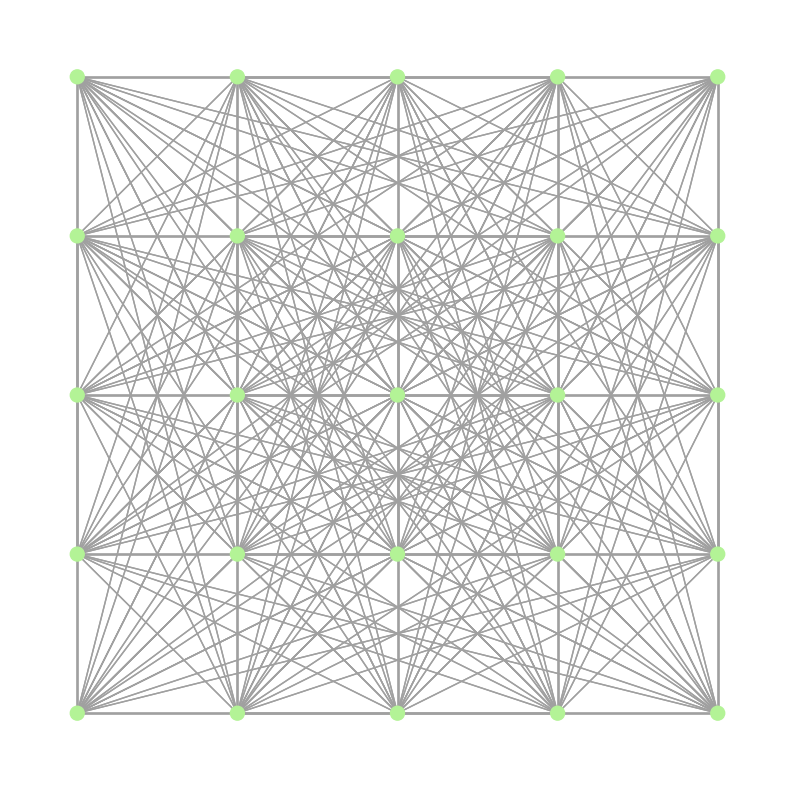

In [127]:
neutral_atom = {
        "type": "tiled_k_nearest",
        "n_blocks_row": 1,
        "n_blocks_col": 1,
        "n" : 5,
        "m": 5,
        "k_intra":25,
        "k_inter": 1,
        
    }
args = {"topology": neutral_atom, "profile": profile}
neutral_atom = FTTarget(args)
neutral_atom.plot()

To transpile a circuit onto a specific hardware arcitecture, all you have to do is specify the appropriate gates alongside error/duration. All qiskit gates are accepted and can be modified accordingly

In [ ]:
## since increasing depth correlates only to a different duration, we can 

#What if we were to arbitrarily increase the distance of our surface code and analyze the success fidelity with these parameters?
top = {
        "type": "tiled_k_nearest",
        "n_blocks_row": 1,
        "n_blocks_col": 1,
        "n" : 10,
        "m": 10,
        "k_intra":1,
        "k_inter": 1,
        
    }
targets = {}
circuits = []

for dist in range(3, 23, 2):
    d = dist
    
    profile = {
        "sq_gates": {
            "RZGate": {
                "error": d * p_L(d, p_phys), 
                # Arbitrary phase rotations require Magic State Distillation and synthesis in FT
                "duration": 15 * d * t_c  
            },
            "XGate": {
                "error": d * p_L(d, p_phys), 
                # X is a Pauli (Clifford), so it is fast (often transversal)
                "duration": d * t_c
            },
            "SXGate": {
                "error": d * p_L(d, p_phys), 
                # SX (sqrt-X) is a Clifford gate, so it is fast
                "duration": d * t_c
            }
        },
        "two_q_gates": {
            "CXGate": {
                # CX is a Clifford performed via Lattice Surgery
                "local_error": d * p_L(d, p_phys), 
                "local_duration": d * t_c
            }
        },
        "inter_device_gates": {
            "CXGate": {
                # Represents inter-block gate teleportation, manually injected 0.5% error rate 
                "inter_error": 0.05, 
                "inter_duration": 2 * d * t_c
            }
        }
    }

    args = {"topology": top, "profile": profile}
    tar = FTTarget(args)
    targets[f"distance {d}"] = tar
    pm = generate_preset_pass_manager(target=tar, optimization_level=3, seed_transpiler=67, scheduling_method="alap")
    circuits.append(pm.run(qc))
    print(f"done with distance {d} ")


done with depth 3 
done with depth 5 
done with depth 7 
done with depth 9 
done with depth 11 
done with depth 13 
done with depth 15 
done with depth 17 
done with depth 19 
done with depth 21 


In [140]:
import matplotlib.pyplot as plt

def plot_paired_error_scaling(circuits_list, targets_dict):
    """
    Calculates and plots the total logical error probability where each 
    transpiled circuit uniquely pairs with a specific target distance.
    """
    distances = []
    circuit_error_probs = []

    # Zip the dictionary items and the circuits list together so they evaluate 1-to-1
    for (d_label, target), transpiled_circuit in zip(targets_dict.items(), circuits_list):
        
        # Extract the integer 'd' from the dictionary key
        d = int(d_label.split()[-1])
        distances.append(d)
        
        success_prob = 1.0
        
        # Iterate through every physical instruction in this specific distance's circuit
        for instruction in transpiled_circuit.data:
            gate_name = instruction.operation.name
            
            # Ignore compiler directives and idle time
            if gate_name in ['barrier', 'delay', 'measure']:
                continue
                
            # Get the physical qubit indices this gate acts on
            qubits = tuple(transpiled_circuit.find_bit(q).index for q in instruction.qubits)
            
            # Query the target for the exact error rate on this specific edge/qubit
            gate_error = target[gate_name][qubits].error
            
            if gate_error is not None:
                success_prob *= (1 - gate_error)
                
        # Total circuit error is 1 minus the chance that everything succeeded
        circuit_error_probs.append(1 - success_prob)

    # ==========================================
    # Matplotlib Plotting Logic
    # ==========================================
    plt.figure(figsize=(10, 6))
    
    # Plot the single curve representing this specific base circuit's scaling
    plt.plot(distances, circuit_error_probs, marker='o', linestyle='-', color='teal', linewidth=2, markersize=8)
    plt.yscale('log')
    
    plt.xlabel("Surface Code Distance (d)", fontsize=12, fontweight='bold')
    plt.ylabel("Overall Circuit Error Probability", fontsize=12, fontweight='bold')
    
    # Grab the scheduled depth of the first circuit just to give context in the title
    base_depth = circuits_list[0].depth() if circuits_list else "Unknown"
    plt.title(f"Logical Error Scaling vs Distance\n(Circuit Depth at d=3: {base_depth})", fontsize=14)
    
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.xticks(distances) # Ensure only the tested odd distances show on the X-axis
    
    plt.tight_layout()
    plt.show()
    
    return distances, circuit_error_probs

# Example usage (run this after your generation loop finishes):
# dists, errors = plot_paired_error_scaling(circuits, targets)

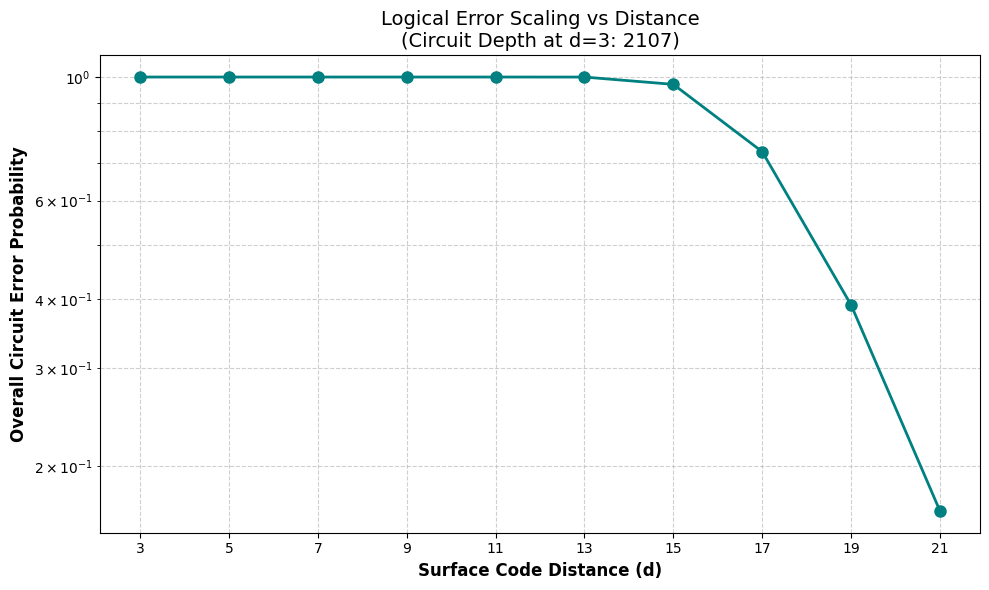

In [141]:
dists, errors = plot_paired_error_scaling(circuits, targets)

In [ ]:
## same process, but now with a 2x2 grid. 
top = {
        "type": "tiled_k_nearest",
        "n_blocks_row": 2,
        "n_blocks_col": 2,
        "n" : 5,
        "m": 5,
        "k_intra":1,
        "k_inter": 1,
        
    }
targets = {}
circuits = []

for dist in range(3, 31, 2):
    d = dist
    
    profile = {
        "sq_gates": {
            "RZGate": {
                "error": d * p_L(d, p_phys), 
                # Arbitrary phase rotations require Magic State Distillation and synthesis in FT
                "duration": 15 * d * t_c  
            },
            "XGate": {
                "error": d * p_L(d, p_phys), 
                # X is a Pauli (Clifford), so it is fast (often transversal)
                "duration": d * t_c
            },
            "SXGate": {
                "error": d * p_L(d, p_phys), 
                # SX (sqrt-X) is a Clifford gate, so it is fast
                "duration": d * t_c
            }
        },
        "two_q_gates": {
            "CXGate": {
                # CX is a Clifford performed via Lattice Surgery
                "local_error": d * p_L(d, p_phys), 
                "local_duration": d * t_c
            }
        },
        "inter_device_gates": {
            "CXGate": {
                # Represents inter-block gate teleportation, manually injected 0.5% error rate 
                "inter_error": 0.05, 
                "inter_duration": 2 * d * t_c
            }
        }
    }

    args = {"topology": top, "profile": profile}
    tar = FTTarget(args)
    targets[f"distance {d}"] = tar
    pm = generate_preset_pass_manager(target=tar, optimization_level=3, seed_transpiler=67, scheduling_method="alap")
    circuits.append(pm.run(qc))
    print(f"done with distance {d} ")


done with distance 3 
done with distance 5 
done with distance 7 
done with distance 9 
done with distance 11 
done with distance 13 
done with distance 15 
done with distance 17 
done with distance 19 
done with distance 21 


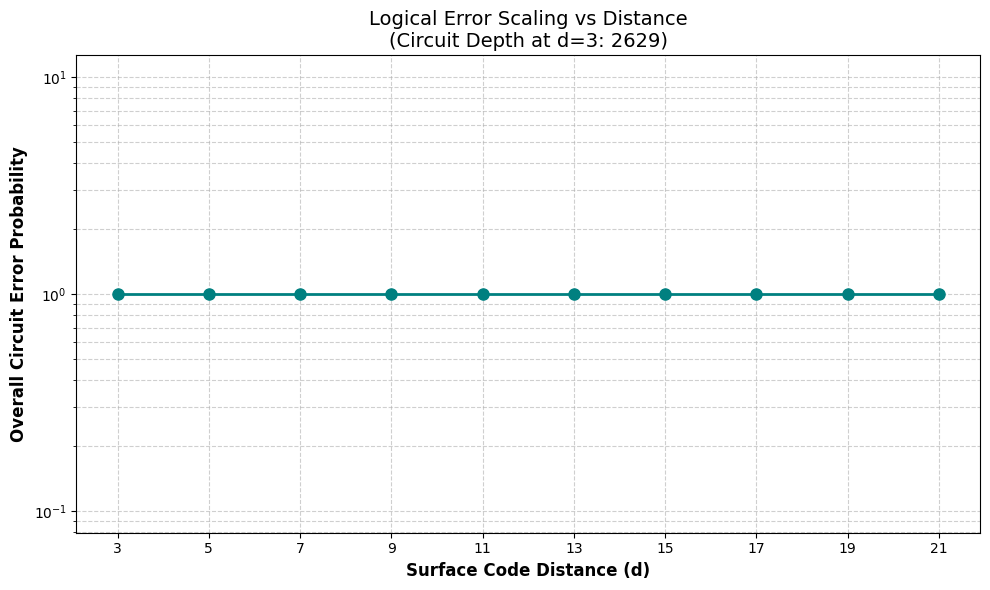

In [143]:
dists, errors = plot_paired_error_scaling(circuits, targets)

These fault-tolerant implementations then have to be mapped onto a given fault-tolerant arcitecture. Qiskit supports the creation of Heavy Hex and Heavy Square surface code blocks, which is what inspired the error rate and error threshold in this example. Future work on this project would involve a way to map a given transpiled circuit of gates with the given protocol for that gate's implementation on fault tolerant device. The mapping of a gate to some protocol would depend on the process and arcitecture of magic state distillation, transversal gates, and lattice surgery, but the FTTarget tool can be initialized to simulate these bounds simply by adding logical gate operations and encoding the relative cost of them into the 'error' profile of the gate. 

As qiskit had no naitive way to tile these heavy hex or heavy square modules for a given depth, the FTTarget also includes a method to construct a given tiling of distance d, with measurement qubits placed between border data qubits to mirror an actual implementation of the surface code

In [128]:
top2 = {
    "type": "heavy_hex",
    "n_blocks_row": 4,
    "n_blocks_col": 4,
    "d": 3,
}
args2 = {"topology": top2, "profile": profile}
targs2 = FTTarget(args2)

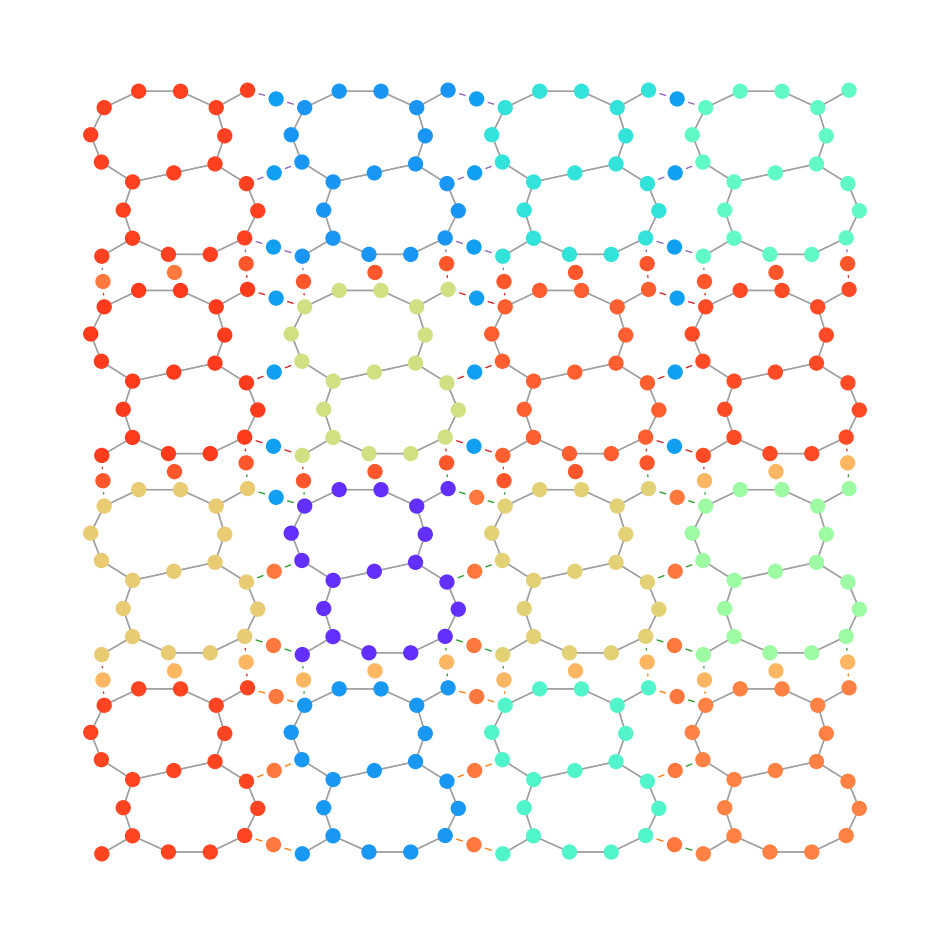

In [129]:
targs2.plot()

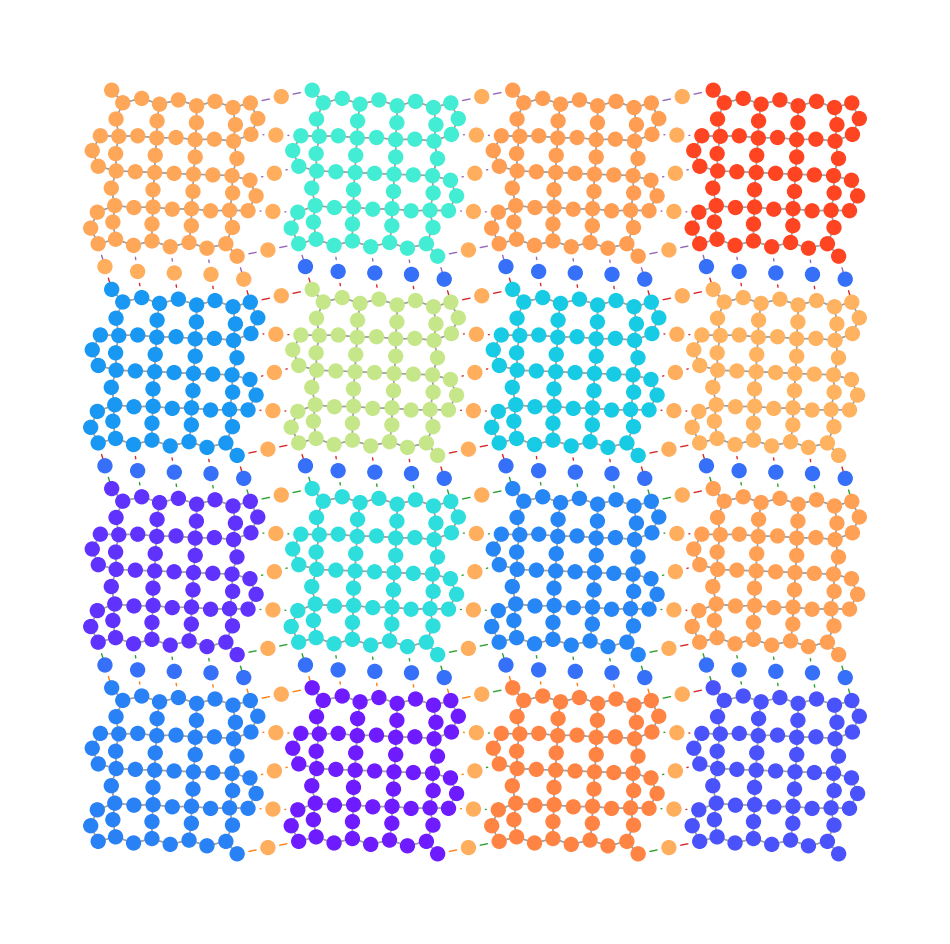

In [38]:
top2 = {
    "type": "heavy_square",
    "n_blocks_row": 4,
    "n_blocks_col": 4,
    "d": 5,
}
args2 = {"topology": top2, "profile": profile}
targs2 = FTTarget(args2)
targs2.plot()
